
# Práctica de Procesamiento de Audio con FFmpeg, MediaInfo y Python

## Paso 1 – Análisis del audio original con MediaInfo
Archivo: `AnalisisTextos.mp3`

- Formato: MP3  
- Tasa de bits: 256 kb/s  
- Canales: 1 canal (mono)  
- Frecuencia de muestreo: 48 kHz  

---

## Paso 2 – Sampleo con ffmpeg
Se realizó el sampleo del archivo con el siguiente comando:

```powershell
.\ffmpeg.exe -i AnalisisTextos.mp3 -ar 22050 sampleo.wav
```

---

## Paso 3 – Nuevo análisis con MediaInfo
Archivo: `sampleo.wav`

- Formato: PCM  
- Tasa de bits: 352,8 kb/s  
- Canales: 1 canal (mono)  
- Frecuencia de muestreo: 22,05 kHz  
- Profundidad de bits: 16 bits  
- Duración: 7 s  


---

## 📌 Paso 4 – Python: análisis del WAV

In [4]:
import numpy as np
import wave

# Abrir el archivo WAV
with wave.open("sampleo.wav", "rb") as wav_file:
    n_channels = wav_file.getnchannels()
    sample_width = wav_file.getsampwidth()
    framerate = wav_file.getframerate()
    n_frames = wav_file.getnframes()
    duration = n_frames / framerate
    signal = np.frombuffer(wav_file.readframes(n_frames), dtype=np.int16)

print("Vector de la señal (primeros 20 valores):", signal[:20])
print("Cantidad de elementos:", len(signal))
print("Frecuencia de muestreo:", framerate, "Hz")
print("Duración:", round(duration, 2), "segundos")

Vector de la señal (primeros 20 valores): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Cantidad de elementos: 155056
Frecuencia de muestreo: 22050 Hz
Duración: 7.03 segundos


---

## 📌 Paso 5 – Imprimir la señal sonora (forma de onda)

El sonido empieza en la muestra: 11891
Tiempo aproximado: 0.54 segundos


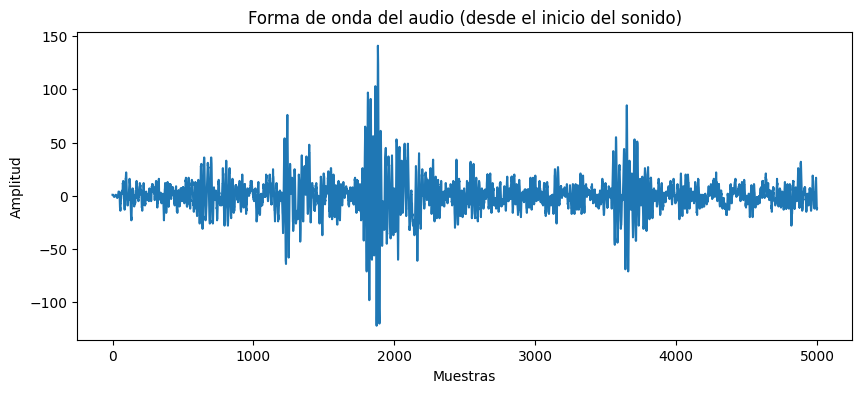

In [ ]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

rate, data = wavfile.read("sampleo.wav")

# Buscar el primer índice donde la señal no es cero
nonzero_indices = np.where(data != 0)[0]

if len(nonzero_indices) > 0:
    first_sound = nonzero_indices[0]
    print("El sonido empieza en la muestra:", first_sound)
    print("Tiempo aproximado:", round(first_sound / rate, 2), "segundos")
else:
    print("La señal es completamente silenciosa.")

# Graficamos parte con sonido
plt.figure(figsize=(10,4))
plt.plot(data[first_sound:first_sound+5000])  # graficar 5000 muestras desde que empieza el sonido
plt.title("Forma de onda del audio (desde el inicio del sonido)")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()


---

## 📌 Paso 6 – Reproducir la señal original


In [6]:
from IPython.display import Audio

Audio("AnalisisTextos.mp3")


---

## 📌 Paso 7 – Modificar la frecuencia de muestreo con Python


In [7]:
import scipy.signal as sps
from scipy.io import wavfile

rate, data = wavfile.read("sampleo.wav")

# Más lento (11.025 Hz)
new_rate_low = rate // 2
num_samples_low = round(len(data) * float(new_rate_low) / rate)
resampled_low = sps.resample(data, num_samples_low)

print("Original:", rate, "Hz")
print("Más lento:", new_rate_low, "Hz")

Audio(resampled_low, rate=new_rate_low)

Original: 22050 Hz
Más lento: 11025 Hz


In [8]:
# Más rápido (44.1 kHz)
new_rate_high = rate * 2
num_samples_high = round(len(data) * float(new_rate_high) / rate)
resampled_high = sps.resample(data, num_samples_high)

print("Más rápido:", new_rate_high, "Hz")

Audio(resampled_high, rate=new_rate_high)

Más rápido: 44100 Hz



**Explicación:**  
- Menor frecuencia → audio más lento y grave.  
- Mayor frecuencia → audio más rápido y agudo.  



---

## 📌 Paso 8 – Bajar la calidad del audio con Python


In [11]:
from scipy.io import wavfile
import numpy as np
from IPython.display import Audio

rate, data = wavfile.read("sampleo.wav")

# Normalizar a rango 0–255 y convertir a uint8
data_uint8 = ((data.astype(np.float32) + 32768) / 256).astype(np.uint8)

# Guardar como WAV de baja calidad
wavfile.write("baja_calidad.wav", rate, data_uint8)

# Reproducir
Audio("baja_calidad.wav")




**Explicación:**  
- Al reducir la profundidad de bits, se pierde resolución en la amplitud.  
- El sonido se escucha con más ruido y menos fidelidad.  

